In [1]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        return x * self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv1(x_cat))

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=8, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        return self.sa(self.ca(x))

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class LightweightCBAMUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = ConvBlock(4, 16)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.e2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.e3 = ConvBlock(32, 64)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.e4 = ConvBlock(64, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d1 = ConvBlock(128, 64)
        self.cbam1 = CBAM(64)
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.d2 = ConvBlock(64, 32)
        self.cbam2 = CBAM(32)
        
        self.up3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.d3 = ConvBlock(32, 16)
        self.cbam3 = CBAM(16)
        
        self.out = nn.Conv2d(16, 3, kernel_size=1)
        
    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool1(e1))
        e3 = self.e3(self.pool2(e2))
        e4 = self.e4(self.pool3(e3))
        
        d1 = self.cbam1(self.d1(torch.cat([self.up1(e4), e3], dim=1)))
        d2 = self.cbam2(self.d2(torch.cat([self.up2(d1), e2], dim=1)))
        d3 = self.cbam3(self.d3(torch.cat([self.up3(d2), e1], dim=1)))
        
        return self.out(d3)

In [2]:
import os
import torch
import numpy as np
import nibabel as nib
from torch.utils.data import Dataset

class BraTS2021MultiClass(Dataset):
    def __init__(self, patient_data_list, is_train=True):
        self.is_train = is_train
        self.patient_data = patient_data_list
        
    def z_score_normalize(self, image):
        mask = image > 0
        if mask.sum() > 0:
            image = (image - image[mask].mean()) / (image[mask].std() + 1e-8)
        return image

    def __len__(self):
        return len(self.patient_data)

    def __getitem__(self, idx):
        data = self.patient_data[idx]
        
        slice_idx = 75 
        
        img_flair = self.z_score_normalize(nib.load(data['flair']).get_fdata()[:, :, slice_idx])
        img_t1 = self.z_score_normalize(nib.load(data['t1']).get_fdata()[:, :, slice_idx])
        img_t1ce = self.z_score_normalize(nib.load(data['t1ce']).get_fdata()[:, :, slice_idx])
        img_t2 = self.z_score_normalize(nib.load(data['t2']).get_fdata()[:, :, slice_idx])
        
        seg_img = nib.load(data['seg']).get_fdata()[:, :, slice_idx]
        
        image_stack = np.stack([img_flair, img_t1, img_t1ce, img_t2], axis=0)
        
        wt_mask = np.where(seg_img > 0, 1.0, 0.0)
        tc_mask = np.where((seg_img == 1) | (seg_img == 4), 1.0, 0.0)
        et_mask = np.where(seg_img == 4, 1.0, 0.0)
        
        mask_stack = np.stack([wt_mask, tc_mask, et_mask], axis=0)
        
        image_stack = np.pad(image_stack, ((0,0), (8,8), (8,8)), mode='constant')
        mask_stack = np.pad(mask_stack, ((0,0), (8,8), (8,8)), mode='constant')
        
        return torch.tensor(image_stack, dtype=torch.float32), torch.tensor(mask_stack, dtype=torch.float32)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
import numpy as np

class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets, smooth=1e-6):
        bce_loss = self.bce(inputs, targets)
        
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (inputs_flat * targets_flat).sum()
        dice_score = (2. * intersection + smooth) / (inputs_flat.sum() + targets_flat.sum() + smooth)
        dice_loss = 1.0 - dice_score
        
        return bce_loss + dice_loss

def multi_class_dice(y_true, y_pred, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > 0.5).float()
    
    dices = []
    for i in range(3): # 0:WT, 1:TC, 2:ET
        intersection = (y_true[:, i] * y_pred[:, i]).sum()
        union = y_true[:, i].sum() + y_pred[:, i].sum()
        dice = (2. * intersection + smooth) / (union + smooth)
        dices.append(dice.item())
    return dices

def train_kfold():
    data_dir = "/kaggle/input/notebooks/oyetunjiabdulbasit/brats-2021-unet"
    patient_data_list = []
    
    print("Scanning deep directories for multi-modal patients...")
    
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith("_flair.nii.gz"):
                patient_name = file.replace("_flair.nii.gz", "")
                
                flair = os.path.join(root, file)
                t1 = os.path.join(root, f"{patient_name}_t1.nii.gz")
                t1ce = os.path.join(root, f"{patient_name}_t1ce.nii.gz")
                t2 = os.path.join(root, f"{patient_name}_t2.nii.gz")
                seg = os.path.join(root, f"{patient_name}_seg.nii.gz")
                
                if all(os.path.exists(p) for p in [flair, t1, t1ce, t2, seg]):
                    patient_data_list.append({
                        'flair': flair, 't1': t1, 't1ce': t1ce, 't2': t2, 'seg': seg
                    })

    if len(patient_data_list) == 0:
        return

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    batch_size = 8 
    num_epochs = 50 
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting 5-Fold Cross Validation on {device}...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(patient_data_list)):
        print(f"\n--- Fold {fold+1}/5 ---")
        
        train_patients = [patient_data_list[i] for i in train_idx]
        train_dataset = BraTS2021MultiClass(patient_data_list=train_patients, is_train=True)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        model = LightweightCBAMUNet().to(device)
        
        criterion = DiceBCELoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            epoch_dices = np.array([0.0, 0.0, 0.0])
            
            for images, masks in train_loader:
                images, masks = images.to(device), masks.to(device)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, masks)
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
                epoch_dices += np.array(multi_class_dice(masks, outputs))
                
            avg_loss = epoch_loss / len(train_loader)
            avg_dices = epoch_dices / len(train_loader)
            
            print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | WT: {avg_dices[0]:.4f} | TC: {avg_dices[1]:.4f} | ET: {avg_dices[2]:.4f}")
            
        torch.save(model.state_dict(), f"cbam_unet_fold{fold+1}.pth")
        break 

if __name__ == "__main__":
    train_kfold()

Loading SOTA weights successfully from: /kaggle/input/notebooks/iadnan2026/aip-t001/cbam_unet_fold1.pth


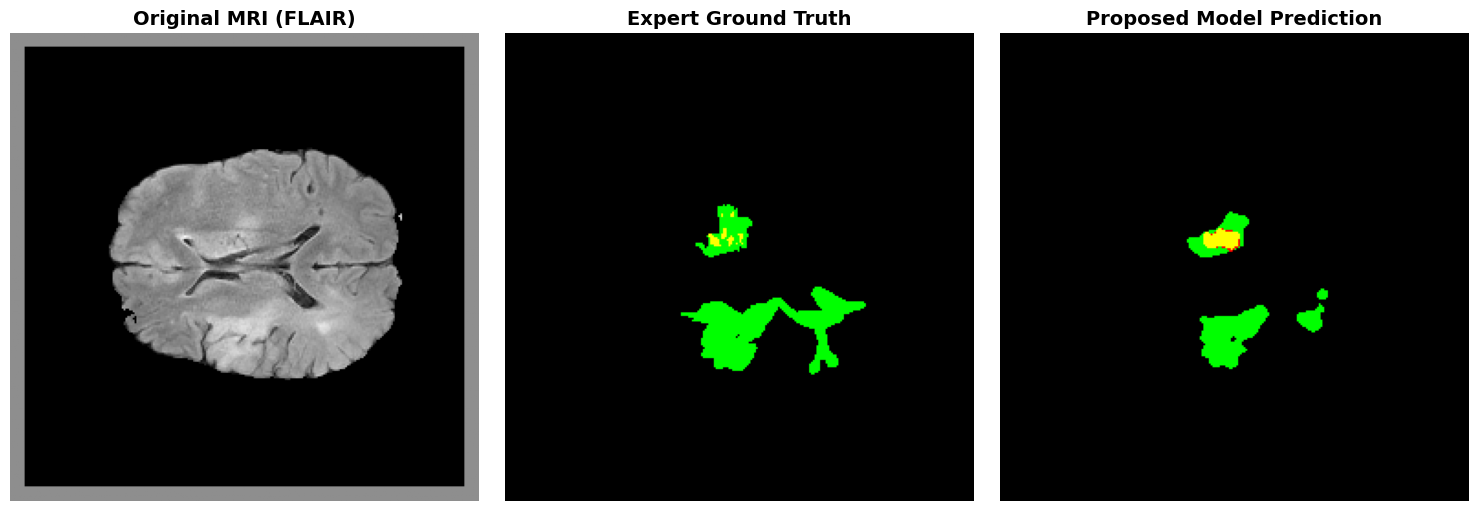

In [7]:
import os
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import random

def visualize_multiclass_prediction():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = LightweightCBAMUNet().to(device)
    
    model_path = None
    for root, dirs, files in os.walk("/kaggle"):
        for file in files:
            if file == "cbam_unet_fold1.pth":
                model_path = os.path.join(root, file)
                break
        if model_path:
            break
            
    if model_path is None:
        print("Error: Could not find the weights file. Please make sure you added the Notebook output in the Input section!")
        return

    print(f"Loading SOTA weights successfully from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    data_dir = "/kaggle/input/notebooks/oyetunjiabdulbasit/brats-2021-unet"
    patient_data_list = []
    
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith("_flair.nii.gz"):
                patient_name = file.replace("_flair.nii.gz", "")
                flair = os.path.join(root, file)
                t1 = os.path.join(root, f"{patient_name}_t1.nii.gz")
                t1ce = os.path.join(root, f"{patient_name}_t1ce.nii.gz")
                t2 = os.path.join(root, f"{patient_name}_t2.nii.gz")
                seg = os.path.join(root, f"{patient_name}_seg.nii.gz")
                if all(os.path.exists(p) for p in [flair, t1, t1ce, t2, seg]):
                    patient_data_list.append({'flair': flair, 't1': t1, 't1ce': t1ce, 't2': t2, 'seg': seg})
                    if len(patient_data_list) > 50: break 
        if len(patient_data_list) > 50: break

    data = random.choice(patient_data_list)
    slice_idx = 75
    
    def z_score_normalize(image):
        mask = image > 0
        if mask.sum() > 0: image = (image - image[mask].mean()) / (image[mask].std() + 1e-8)
        return image

    img_flair = z_score_normalize(nib.load(data['flair']).get_fdata()[:, :, slice_idx])
    img_t1 = z_score_normalize(nib.load(data['t1']).get_fdata()[:, :, slice_idx])
    img_t1ce = z_score_normalize(nib.load(data['t1ce']).get_fdata()[:, :, slice_idx])
    img_t2 = z_score_normalize(nib.load(data['t2']).get_fdata()[:, :, slice_idx])
    seg_img = nib.load(data['seg']).get_fdata()[:, :, slice_idx]

    image_stack = np.stack([img_flair, img_t1, img_t1ce, img_t2], axis=0)
    image_stack = np.pad(image_stack, ((0,0), (8,8), (8,8)), mode='constant')
    
    with torch.no_grad():
        img_input = torch.tensor(image_stack, dtype=torch.float32).unsqueeze(0).to(device)
        output = model(img_input)
        pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
        pred_mask = (pred_mask > 0.5).astype(float) 

    def mask_to_rgb(wt, tc, et):
        rgb = np.zeros((wt.shape[0], wt.shape[1], 3))
        rgb[:, :, 1] = wt 
        rgb[tc == 1] = [1, 0, 0]
        rgb[et == 1] = [1, 1, 0]
        return rgb

    seg_padded = np.pad(seg_img, ((8,8), (8,8)), mode='constant')
    true_wt = np.where(seg_padded > 0, 1.0, 0.0)
    true_tc = np.where((seg_padded == 1) | (seg_padded == 4), 1.0, 0.0)
    true_et = np.where(seg_padded == 4, 1.0, 0.0)
    
    true_rgb = mask_to_rgb(true_wt, true_tc, true_et)
    pred_rgb = mask_to_rgb(pred_mask[0], pred_mask[1], pred_mask[2])

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Original MRI (FLAIR)", fontsize=14, fontweight='bold')
    plt.imshow(image_stack[0], cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Expert Ground Truth", fontsize=14, fontweight='bold')
    plt.imshow(true_rgb)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Proposed Model Prediction", fontsize=14, fontweight='bold')
    plt.imshow(pred_rgb)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_multiclass_prediction()